In [128]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

In [3]:
file_path = (r"C:\Users\sneha\anaconda_projects\KMean, PCA case study\telco_csv.csv")

In [4]:
data = pd.read_csv(file_path)

In [5]:
data.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,callwait,forward,confer,longmon,tollmon,equipmon,cardmon,wiremon,ebill,custcat
0,2,13,44,1,9,64,4,5,0,0,...,0,1,0,3.70,0.00,0.0,7.50,0.0,0,1
1,3,11,33,1,7,136,5,5,0,0,...,1,1,1,4.40,20.75,0.0,15.25,35.7,0,4
2,3,68,52,1,24,116,1,29,0,1,...,1,0,1,18.15,18.00,0.0,30.25,0.0,0,3
3,2,33,33,0,12,33,2,0,0,1,...,0,0,0,9.45,0.00,0.0,0.00,0.0,0,1
4,2,23,30,1,9,30,1,2,0,0,...,0,1,1,6.30,0.00,0.0,0.00,0.0,0,3


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   region    1000 non-null   int64  
 1   tenure    1000 non-null   int64  
 2   age       1000 non-null   int64  
 3   marital   1000 non-null   int64  
 4   address   1000 non-null   int64  
 5   income    1000 non-null   int64  
 6   ed        1000 non-null   int64  
 7   employ    1000 non-null   int64  
 8   retire    1000 non-null   int64  
 9   gender    1000 non-null   int64  
 10  reside    1000 non-null   int64  
 11  tollfree  1000 non-null   int64  
 12  equip     1000 non-null   int64  
 13  callcard  1000 non-null   int64  
 14  wireless  1000 non-null   int64  
 15  multline  1000 non-null   int64  
 16  voice     1000 non-null   int64  
 17  pager     1000 non-null   int64  
 18  internet  1000 non-null   int64  
 19  callid    1000 non-null   int64  
 20  callwait  1000 non-null   int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
def outlier_capping(x):
    x = x.clip(upper = x.quantile(0.99)+0.5*x.std(), lower = x.quantile(0.01)-0.5*x.std())
    return x

In [12]:
data=data.apply(outlier_capping)

In [13]:
data

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,callwait,forward,confer,longmon,tollmon,equipmon,cardmon,wiremon,ebill,custcat
0,2,13,44.0,1,9.0,64.000000,4,5.0,0,0,...,0,1,0,3.70,0.00,0.00,7.50,0.0,0,1
1,3,11,33.0,1,7.0,136.000000,5,5.0,0,0,...,1,1,1,4.40,20.75,0.00,15.25,35.7,0,4
2,3,68,52.0,1,24.0,116.000000,1,29.0,0,1,...,1,0,1,18.15,18.00,0.00,30.25,0.0,0,3
3,2,33,33.0,0,12.0,33.000000,2,0.0,0,1,...,0,0,0,9.45,0.00,0.00,0.00,0.0,0,1
4,2,23,30.0,1,9.0,30.000000,1,2.0,0,0,...,0,1,1,6.30,0.00,0.00,0.00,0.0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,10,39.0,0,0.0,27.000000,3,0.0,0,1,...,0,0,0,3.00,0.00,29.05,0.00,0.0,1,1
996,1,7,34.0,0,2.0,22.000000,5,5.0,0,1,...,0,0,0,4.65,0.00,25.60,0.00,0.0,0,1
997,3,67,59.0,0,40.0,514.002082,5,33.0,0,1,...,1,1,1,26.75,32.00,54.55,35.75,65.8,1,4
998,3,70,49.0,0,18.0,87.000000,2,22.0,0,1,...,1,1,1,25.60,33.50,0.00,25.25,0.0,0,3


In [15]:
std =StandardScaler()

In [17]:
std=std.fit(data)

In [18]:
std.transform(data)

array([[-0.02696767, -1.055125  ,  0.18459027, ..., -0.59493588,
        -0.76800073, -1.32797979],
       [ 1.19883553, -1.14880563, -0.69186491, ...,  1.2545082 ,
        -0.76800073,  1.35119935],
       [ 1.19883553,  1.52109247,  0.82201223, ..., -0.59493588,
        -0.76800073,  0.45813963],
       ...,
       [ 1.19883553,  1.47425216,  1.37975644, ...,  2.81384341,
         1.3020821 ,  1.35119935],
       [ 1.19883553,  1.61477311,  0.582979  , ..., -0.59493588,
        -0.76800073,  0.45813963],
       [ 1.19883553,  0.67796676, -0.45283168, ..., -0.59493588,
         1.3020821 , -0.43492008]])

In [19]:
data_std = pd.DataFrame(std.transform(data), columns=data.columns)

In [20]:
data_std

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,callwait,forward,confer,longmon,tollmon,equipmon,cardmon,wiremon,ebill,custcat
0,-0.026968,-1.055125,0.184590,1.010051,-0.253031,-0.128236,1.087753,-0.594329,-0.222076,-1.034598,...,-0.970437,1.014099,-1.004008,-0.822937,-0.817320,-0.746761,-0.454483,-0.594936,-0.768001,-1.327980
1,1.198836,-1.148806,-0.691865,1.010051,-0.452026,0.768343,1.906227,-0.594329,-0.222076,-1.034598,...,1.030464,1.014099,0.996008,-0.750003,0.474004,-0.746761,0.114902,1.254508,-0.768001,1.351199
2,1.198836,1.521092,0.822012,1.010051,1.239433,0.519293,-1.367671,1.788925,-0.222076,0.966559,...,1.030464,-0.986097,0.996008,0.682614,0.302865,-0.746761,1.216938,-0.594936,-0.768001,0.458140
3,-0.026968,-0.118319,-0.691865,-0.990050,0.045462,-0.514263,-0.549196,-1.090840,-0.222076,0.966559,...,-0.970437,-0.986097,-1.004008,-0.223842,-0.817320,-0.746761,-1.005501,-0.594936,-0.768001,-1.327980
4,-0.026968,-0.586722,-0.930898,1.010051,-0.253031,-0.551620,-1.367671,-0.892236,-0.222076,-1.034598,...,-0.970437,1.014099,0.996008,-0.552042,-0.817320,-0.746761,-1.005501,-0.594936,-0.768001,0.458140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.198836,-1.195646,-0.213798,-0.990050,-1.148509,-0.588978,0.269278,-1.090840,-0.222076,0.966559,...,-0.970437,-0.986097,-1.004008,-0.895870,-0.817320,0.779838,-1.005501,-0.594936,1.302082,-1.327980
996,-1.252771,-1.336167,-0.612187,-0.990050,-0.949514,-0.651240,1.906227,-0.594329,-0.222076,0.966559,...,-0.970437,-0.986097,-1.004008,-0.723956,-0.817320,0.598538,-1.005501,-0.594936,-0.768001,-1.327980
997,1.198836,1.474252,1.379756,-0.990050,2.831394,5.475406,1.906227,2.186134,-0.222076,0.966559,...,1.030464,1.014099,0.996008,1.578651,1.174120,2.119882,1.621018,2.813843,1.302082,1.351199
998,1.198836,1.614773,0.582979,-0.990050,0.642447,0.158171,-0.549196,1.093809,-0.222076,0.966559,...,1.030464,1.014099,0.996008,1.458832,1.267468,-0.746761,0.849593,-0.594936,-0.768001,0.458140


In [22]:
KMeans?

Init signature:
KMeans(
    n_clusters=8,
    *,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm='lloyd',
)
Docstring:     
K-Means clustering.

Read more in the :ref:`User Guide <k_means>`.

Parameters
----------

n_clusters : int, default=8
    The number of clusters to form as well as the number of
    centroids to generate.

    For an example of how to choose an optimal value for `n_clusters` refer to
    :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.

init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
    Method for initialization:

    * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to the overall inertia. This technique speeds up             convergence. The algorithm imple

In [73]:
par_grid_kmean = {'n_clusters':np.arange(0,5)}

In [74]:
grid_cv_kmean = GridSearchCV(KMeans(),param_grid=par_grid_kmean,cv=5,n_jobs=-1)

In [75]:
grid_cv_kmean=grid_cv_kmean.fit(data_std)

In [76]:
kmean = grid_cv_kmean.best_estimator_

In [77]:
kmean = kmean.fit(data_std)

In [78]:
kmean.predict

<bound method _BaseKMeans.predict of KMeans(n_clusters=np.int64(4))>

In [79]:
kmean.cluster_centers_

array([[-2.69676703e-02,  8.74743167e-01,  5.88700343e-01,
         1.05482661e-01,  5.88491870e-01,  8.47704967e-02,
        -2.98307219e-01,  4.56578177e-01,  2.29057134e-01,
         4.14008210e-02, -1.09986922e-01, -7.27879231e-01,
        -2.76777442e-01,  6.24619867e-01, -5.60359383e-01,
         3.16727816e-01, -4.97025564e-01, -5.02752941e-01,
        -2.62915476e-01, -8.11832586e-01, -7.49231703e-01,
        -7.04662025e-01, -6.52246424e-01,  6.71957755e-01,
        -6.69322083e-01, -3.02363615e-01,  5.12860634e-01,
        -5.37663848e-01, -2.58281842e-01, -6.27892782e-01],
       [ 3.58940321e-02,  2.95523285e-01,  3.74299190e-01,
         5.02955551e-02,  2.65231135e-01,  2.67142335e-01,
        -4.47261834e-01,  4.66004748e-01,  1.93310865e-01,
        -1.03356461e-03, -6.85930022e-02,  8.77362822e-01,
        -6.64972498e-01,  4.93158634e-01, -5.46291842e-02,
        -2.17671527e-01, -7.89964570e-03, -1.18877911e-01,
        -5.73184880e-01,  8.04148571e-01,  8.76548382e-

In [80]:
kmean.labels_

array([3, 2, 1, 3, 3, 1, 3, 2, 1, 0, 3, 1, 0, 2, 3, 3, 1, 1, 3, 2, 3, 0,
       2, 0, 1, 1, 2, 3, 3, 3, 0, 2, 1, 3, 2, 3, 2, 1, 1, 1, 1, 1, 3, 2,
       1, 0, 0, 2, 3, 1, 3, 0, 2, 3, 3, 3, 3, 0, 1, 0, 1, 1, 0, 0, 2, 0,
       1, 1, 3, 3, 0, 3, 3, 3, 1, 3, 1, 0, 1, 2, 1, 3, 1, 1, 0, 3, 3, 2,
       2, 1, 3, 3, 2, 2, 3, 2, 1, 0, 1, 0, 2, 0, 1, 3, 3, 3, 0, 2, 3, 0,
       0, 3, 3, 3, 1, 3, 3, 3, 1, 3, 0, 3, 3, 3, 3, 0, 2, 3, 3, 1, 1, 3,
       1, 0, 2, 3, 3, 2, 1, 2, 2, 1, 2, 0, 2, 2, 2, 3, 0, 0, 0, 1, 2, 2,
       2, 1, 3, 3, 3, 1, 1, 1, 0, 3, 0, 0, 2, 3, 3, 0, 2, 1, 2, 3, 0, 3,
       0, 2, 2, 3, 2, 1, 3, 0, 0, 3, 3, 2, 1, 1, 0, 2, 3, 1, 2, 3, 3, 1,
       3, 0, 0, 2, 3, 0, 2, 3, 0, 2, 1, 1, 3, 3, 3, 3, 0, 0, 1, 2, 2, 3,
       3, 3, 3, 1, 3, 1, 2, 2, 1, 1, 1, 1, 0, 3, 2, 0, 2, 2, 3, 1, 0, 1,
       1, 3, 3, 1, 0, 3, 1, 0, 3, 1, 2, 0, 2, 0, 3, 0, 2, 2, 1, 3, 1, 0,
       0, 3, 1, 1, 3, 3, 3, 2, 2, 3, 1, 0, 0, 1, 3, 3, 2, 2, 1, 0, 3, 1,
       1, 1, 1, 0, 2, 0, 3, 1, 2, 2, 1, 0, 2, 3, 1,

In [81]:
silhouette_score(data_std,kmean.labels_)

np.float64(0.14119184436836854)

In [82]:
PCA?

Init signature:
PCA(
    n_components=None,
    *,
    copy=True,
    whiten=False,
    svd_solver='auto',
    tol=0.0,
    iterated_power='auto',
    n_oversamples=10,
    power_iteration_normalizer='auto',
    random_state=None,
)
Docstring:     
Principal component analysis (PCA).

Linear dimensionality reduction using Singular Value Decomposition of the
data to project it to a lower dimensional space. The input data is centered
but not scaled for each feature before applying the SVD.

It uses the LAPACK implementation of the full SVD or a randomized truncated
SVD by the method of Halko et al. 2009, depending on the shape of the input
data and the number of components to extract.

With sparse inputs, the ARPACK implementation of the truncated SVD can be
used (i.e. through :func:`scipy.sparse.linalg.svds`). Alternatively, one
may consider :class:`TruncatedSVD` where the data are not centered.

Notice that this class only supports sparse inputs for some solvers such as
"arpack" and "c

In [83]:
pca = PCA(n_components=10)

In [84]:
pca=pca.fit(data_std)

In [85]:
pca.transform(data_std)

array([[-2.59709362, -0.02222158, -0.79188577, ...,  0.57997697,
        -0.93585175, -0.15827543],
       [ 3.21163171,  0.92299607, -2.88531868, ...,  1.46787517,
        -0.92600907,  1.32626649],
       [ 0.66921569, -3.9627416 , -0.32399735, ...,  0.40399077,
        -0.31684126, -1.04385836],
       ...,
       [ 6.86793653, -1.06222045,  4.46944131, ...,  0.13505372,
        -0.33586063, -0.39262072],
       [ 1.85848746, -3.4203164 , -0.83815105, ..., -0.30363774,
         0.55822088, -0.40622578],
       [-1.46983122,  1.7701002 ,  2.38657735, ...,  0.21746401,
         0.32942175, -1.30554554]])

In [86]:
pca_model = pd.DataFrame(pca.transform(data_std), columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10'])

In [87]:
pca_model

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-2.597094,-0.022222,-0.791886,0.373200,0.172700,-0.667528,-0.782649,0.579977,-0.935852,-0.158275
1,3.211632,0.922996,-2.885319,1.554171,1.339979,-0.023339,0.054895,1.467875,-0.926009,1.326266
2,0.669216,-3.962742,-0.323997,0.405022,0.641364,0.116528,1.490425,0.403991,-0.316841,-1.043858
3,-3.835727,0.139141,-0.531750,-1.026166,-0.122488,0.103659,0.613703,-0.866301,0.109285,1.107183
4,-1.786142,0.007194,-2.630130,1.195782,0.177488,0.540546,-0.837411,0.968811,0.362927,0.232139
...,...,...,...,...,...,...,...,...,...,...
995,-3.287913,2.693321,0.068617,-0.902309,0.124427,0.689435,1.348063,0.455945,-0.154802,-0.615168
996,-3.332497,2.315050,0.056334,-1.289492,0.291719,0.309106,-0.556147,-1.800371,0.033712,-0.377894
997,6.867937,-1.062220,4.469441,-2.162734,3.624753,-0.717673,1.133387,0.135054,-0.335861,-0.392621
998,1.858487,-3.420316,-0.838151,-1.057460,-0.064351,-0.549240,1.619829,-0.303638,0.558221,-0.406226


In [88]:
kmean_pca=kmean.fit(pca_model)

In [89]:
silhouette_score(pca_model,kmean_pca.labels_)

np.float64(0.176429337147735)

In [91]:
k_range = range(3,8)
score = []

for k in k_range:
    kmean_range = KMeans(n_clusters=k,random_state=123)
    kmean_range.fit(pca_model)
    score.append(silhouette_score(pca_model,kmean_range.labels_))

In [93]:
score_data = pd.DataFrame({'range': k_range,'silhouette_score': score})

In [94]:
score_data

,range,silhouette_score
0,3,0.219975
1,4,0.207443
2,5,0.192246
3,6,0.194423
4,7,0.181990


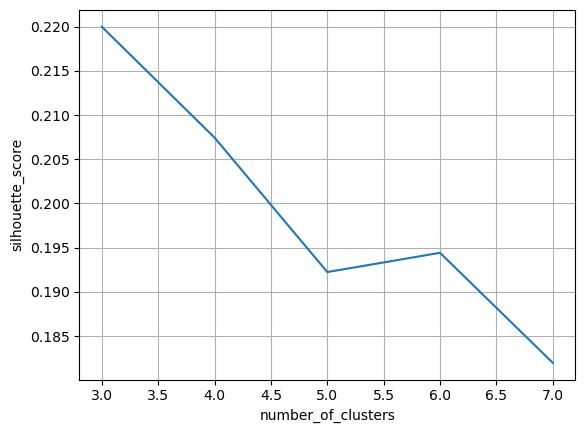

In [104]:
plt.plot(k_range,score)
plt.xlabel('number_of_clusters')
plt.ylabel('silhouette_score')
plt.grid(True)
plt.show()

In [99]:
k_range = range(3,8)
inertia = []

for k in k_range:
    kmean_range = KMeans(n_clusters=k,random_state=123)
    kmean_range.fit(pca_model)
    inertia.append(kmean_range.inertia_)

In [100]:
inertia_data = pd.DataFrame({'range': k_range,'inertia': inertia})

In [101]:
inertia_data

,range,inertia
0,3,14593.343781
1,4,13275.407252
2,5,12161.121510
3,6,11437.011651
4,7,10601.383745


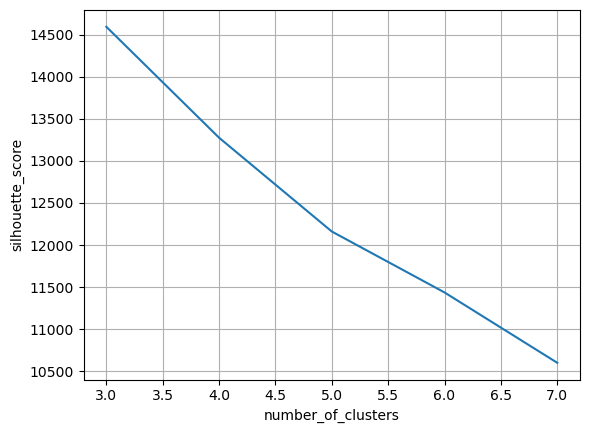

In [105]:
plt.plot(k_range,inertia)
plt.xlabel('number_of_clusters')
plt.ylabel('silhouette_score')
plt.grid(True)
plt.show()

In [90]:
# importing new data

In [107]:
file_path_new = (r"C:\Users\sneha\anaconda_projects\KMean, PCA case study\Telco_new_cust.csv")

In [108]:
data_new = pd.read_csv(file_path_new)

In [109]:
data_new

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,callwait,forward,confer,longmon,tollmon,equipmon,cardmon,wiremon,ebill,custcat
0,1,38,55,1,12,135,2,24,0,0,...,1,1,1,12.15,31.75,0.00,16.25,0.00,1,4
1,3,59,26,1,3,41,4,1,0,1,...,0,0,0,12.65,0.00,35.10,46.75,29.15,0,2
2,2,54,55,0,1,587,3,33,0,0,...,1,1,1,13.00,0.00,0.00,0.00,0.00,0,3
3,3,9,40,0,13,38,4,7,0,1,...,1,1,1,3.35,21.00,42.40,17.50,59.55,1,4
4,1,67,67,1,38,49,2,10,0,1,...,0,0,0,14.30,0.00,29.25,25.25,0.00,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3,24,30,0,0,25,4,5,0,0,...,1,1,1,8.70,47.75,0.00,32.75,64.00,1,4
96,2,3,26,1,6,59,4,0,0,1,...,0,1,1,2.55,23.50,29.60,10.75,19.20,0,4
97,1,4,30,0,1,45,4,6,0,0,...,0,1,1,3.65,0.00,34.20,29.00,0.00,1,4
98,1,72,40,1,19,163,4,15,0,0,...,0,0,1,39.00,31.25,0.00,14.75,0.00,1,2


In [110]:
std = StandardScaler()

In [111]:
std = std.fit(data_new)

In [112]:
std.transform(data_new)

array([[-1.38978198,  0.10660793,  1.02324737, ..., -0.65677687,
         1.1751393 ,  1.25174003],
       [ 1.1143297 ,  1.06334571, -1.43119214, ...,  0.82871706,
        -0.85096294, -0.49894533],
       [-0.13772614,  0.835551  ,  1.02324737, ..., -0.65677687,
        -0.85096294,  0.37639735],
       ...,
       [-1.38978198, -1.44239611, -1.09264876, ..., -0.65677687,
         1.1751393 ,  1.25174003],
       [-1.38978198,  1.65561196, -0.24629031, ..., -0.65677687,
         1.1751393 , -0.49894533],
       [-1.38978198,  0.37996158,  1.10788321, ..., -0.65677687,
        -0.85096294,  0.37639735]])

In [115]:
data_new_std = pd.DataFrame(std.transform(data_new),columns=data_new.columns)

In [116]:
data_new_std

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,callwait,forward,confer,longmon,tollmon,equipmon,cardmon,wiremon,ebill,custcat
0,-1.389782,0.106608,1.023247,1.061913,0.090148,0.274599,-0.482564,1.125764,-0.175863,-0.980196,...,0.904534,0.886405,0.833616,0.088540,1.027979,-0.718927,0.083548,-0.656777,1.175139,1.251740
1,1.114330,1.063346,-1.431192,1.061913,-0.911498,-0.400056,1.099613,-1.104432,-0.175863,1.020204,...,-1.105542,-1.128152,-1.199593,0.140046,-0.993596,1.182394,2.363818,0.828717,-0.850963,-0.498945
2,-0.137726,0.835551,1.023247,-0.941697,-1.134087,3.518687,0.308525,1.998449,-0.175863,-0.980196,...,0.904534,0.886405,0.833616,0.176101,-0.993596,-0.718927,-1.131351,-0.656777,-0.850963,0.376397
3,1.114330,-1.214601,-0.246290,-0.941697,0.201442,-0.421588,1.099613,-0.522641,-0.175863,1.020204,...,0.904534,0.886405,0.833616,-0.817976,0.343508,1.577825,0.177001,2.377911,1.175139,1.251740
4,-1.389782,1.427817,2.038878,1.061913,2.983794,-0.342639,-0.482564,-0.231746,-0.175863,1.020204,...,-1.105542,-1.128152,-1.199593,0.310018,-0.993596,0.865507,0.756414,-0.656777,1.175139,-0.498945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.114330,-0.531217,-1.092649,-0.941697,-1.245381,-0.514891,1.099613,-0.716572,-0.175863,-0.980196,...,0.904534,0.886405,0.833616,-0.266855,2.046725,-0.718927,1.317137,2.604685,1.175139,1.251740
96,-0.137726,-1.487955,-1.431192,1.061913,-0.577616,-0.270867,1.099613,-1.201397,-0.175863,1.020204,...,-1.105542,0.886405,0.833616,-0.900386,0.502688,0.884466,-0.327649,0.321662,-0.850963,1.251740
97,-1.389782,-1.442396,-1.092649,-0.941697,-1.134087,-0.371348,1.099613,-0.619607,-0.175863,-0.980196,...,-1.105542,0.886405,0.833616,-0.787072,-0.993596,1.133642,1.036776,-0.656777,1.175139,1.251740
98,-1.389782,1.655612,-0.246290,1.061913,0.869207,0.475560,1.099613,0.253079,-0.175863,-0.980196,...,-1.105542,-1.128152,0.833616,2.854442,0.996143,-0.718927,-0.028597,-0.656777,1.175139,-0.498945


In [117]:
pca.transform(data_new_std)

array([[ 2.66788241e+00, -7.74966717e-01, -2.48293972e-01,
         1.34687434e+00,  7.28980939e-01,  4.11513814e-01,
        -1.78027043e+00,  2.50523279e-01,  4.48413028e-01,
        -4.78166327e-01],
       [-5.42652546e-01,  2.00353897e+00,  2.42738377e+00,
         2.35579024e+00, -1.35748041e+00, -1.29137984e+00,
         2.26808384e+00, -5.31854947e-01, -8.16439275e-01,
         8.75301809e-02],
       [-1.24935592e-01, -1.83193940e+00, -1.76252761e-01,
        -2.01793654e+00,  3.68772491e+00, -6.27846170e-01,
        -1.23646327e+00,  1.50595869e-01,  5.56440191e-01,
         3.66904785e-01],
       [ 3.92859552e+00,  2.95198355e+00, -3.01616309e-01,
        -2.09416254e+00, -4.51787997e-01,  2.86441478e-01,
         1.35251021e+00,  1.82836570e-02, -1.03616815e+00,
        -2.01927902e-01],
       [-1.32952547e+00, -5.62875447e-01,  4.51266240e+00,
         9.83889538e-01, -9.00658127e-01,  5.70336152e-01,
        -4.72339070e-01, -8.97495702e-01, -6.09768564e-01,
        -1.

In [118]:
pca_new_model = pd.DataFrame(pca.transform(data_new_std),columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10'])

In [119]:
pca_new_model

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,2.667882,-0.774967,-0.248294,1.346874,0.728981,0.411514,-1.780270,0.250523,0.448413,-0.478166
1,-0.542653,2.003539,2.427384,2.355790,-1.357480,-1.291380,2.268084,-0.531855,-0.816439,0.087530
2,-0.124936,-1.831939,-0.176253,-2.017937,3.687725,-0.627846,-1.236463,0.150596,0.556440,0.366905
3,3.928596,2.951984,-0.301616,-2.094163,-0.451788,0.286441,1.352510,0.018284,-1.036168,-0.201928
4,-1.329525,-0.562875,4.512662,0.983890,-0.900658,0.570336,-0.472339,-0.897496,-0.609769,-1.537193
...,...,...,...,...,...,...,...,...,...,...
95,3.996974,1.683552,-1.948947,-0.833819,-0.854655,-1.231132,0.635547,0.874080,-0.678450,1.356531
96,2.135417,2.496224,-1.955657,0.678651,0.136769,0.578753,0.505565,-0.817448,-0.951663,0.072554
97,0.415930,2.911809,-0.339909,-0.143707,-0.898231,-1.270811,-1.324690,-0.849311,-0.899087,-2.188844
98,-0.359346,-2.034380,2.044870,1.640155,-0.076816,-0.936710,-1.421520,-0.532259,1.925350,0.082493


In [120]:
kmean_pca.predict(pca_new_model)

array([1, 3, 1, 2, 3, 3, 3, 3, 2, 3, 2, 2, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2,
       3, 0, 1, 1, 3, 1, 1, 2, 3, 3, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 2, 1,
       2, 3, 0, 1, 0, 1, 0, 3, 2, 0, 1, 2, 2, 0, 2, 3, 3, 2, 0, 2, 2, 0,
       0, 1, 1, 1, 3, 0, 3, 3, 2, 2, 2, 2, 0, 1, 0, 3, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 3, 1, 0, 1, 2, 2, 3, 1, 0], dtype=int32)

In [121]:
pca_new_model['prediction'] = kmean_pca.predict(pca_new_model)

In [122]:
pca_new_model

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,prediction
0,2.667882,-0.774967,-0.248294,1.346874,0.728981,0.411514,-1.780270,0.250523,0.448413,-0.478166,1
1,-0.542653,2.003539,2.427384,2.355790,-1.357480,-1.291380,2.268084,-0.531855,-0.816439,0.087530,3
2,-0.124936,-1.831939,-0.176253,-2.017937,3.687725,-0.627846,-1.236463,0.150596,0.556440,0.366905,1
3,3.928596,2.951984,-0.301616,-2.094163,-0.451788,0.286441,1.352510,0.018284,-1.036168,-0.201928,2
4,-1.329525,-0.562875,4.512662,0.983890,-0.900658,0.570336,-0.472339,-0.897496,-0.609769,-1.537193,3
...,...,...,...,...,...,...,...,...,...,...,...
95,3.996974,1.683552,-1.948947,-0.833819,-0.854655,-1.231132,0.635547,0.874080,-0.678450,1.356531,2
96,2.135417,2.496224,-1.955657,0.678651,0.136769,0.578753,0.505565,-0.817448,-0.951663,0.072554,2
97,0.415930,2.911809,-0.339909,-0.143707,-0.898231,-1.270811,-1.324690,-0.849311,-0.899087,-2.188844,3
98,-0.359346,-2.034380,2.044870,1.640155,-0.076816,-0.936710,-1.421520,-0.532259,1.925350,0.082493,1


In [124]:
pca_new_model.to_csv(r'C:\Users\sneha\anaconda_projects\KMean, PCA case study\new_tel_com_pca_model.csv')